In [1]:
# load modules
%matplotlib inline
import matplotlib.pyplot as plt
# load general modules unrelated to jax
import os, sys

# set for jax on GPU, doesn't affect CPU
os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'false' 

from glob import glob
import multiprocess
import numpy as np
from timeit import default_timer as timer

from astropy import constants as const
from astropy import units as u
from astropy.cosmology import Planck15, FlatLambdaCDM 
from functools import partial 

import seaborn as sns
from matplotlib.colors import LogNorm, SymLogNorm
from mpl_toolkits.axes_grid1.inset_locator import inset_axes


plt.rcParams['figure.dpi'] = 120
plt.rcParams['ytick.right'] = True
plt.rcParams['xtick.top'] = True

# re-generating the data requires 2+ GPUs

due to the huge number of ODE solves across many tolerance and finite-diff epsilon settings 

Viraj Pandya tested it on 8 Nvidia H100's w/ 8 CPUs per GPU (64 CPU core node)

In [2]:
### read a basic config.yaml file and modify below
# it's easier to modify this existing dict than create config from scratch

from sapphire.utils import read_config

config = {'path_config':'/mnt/ceph/users/vpandya/sapphire/demo/pandya26/scripts/benchmark_runtime/config_benchmark.yaml'}

### read config based on user input
config = read_config.get(config,verbose=True) 

reading /mnt/ceph/users/vpandya/sapphire/demo/pandya26/scripts/benchmark_runtime/config_benchmark.yaml

your full sapphire config:

{   'Nbatch': 1000,
    'chain_num': 0,
    'clip_etaE_max': 1.0,
    'coolfunc': 'sd93',
    'data_path': '/mnt/ceph/users/vpandya/sapphire/data/',
    'flag_fgas': 1,
    'flag_mzr': 0,
    'flag_mzr_gas': 1,
    'flag_sfms': 0,
    'flag_smhm': 1,
    'inference_config': {   'Nadam': 10,
                            'adam_logL': 'manual',
                            'engine': 'adam',
                            'fit_mock': False,
                            'fit_obs': True,
                            'num_samples': 1000,
                            'num_warmup': 1000,
                            'random_mock': False,
                            'write_output': True},
    'mock_err_fgas': 0.0,
    'mock_err_mzr': 0.0,
    'mock_err_mzr_gas': 0.0,
    'mock_err_sfms': 0.0,
    'mock_err_smhm': 0.0,
    'model': 'pandya23',
    'num_cpus': 50,
    'obs_nam

In [3]:
### now run sapphire with runtype=finitediff
import sapphire

config['runtype'] = 'finitediff'

config,halo_index,halo_matrix,batch_solve8,batch_solve12 = sapphire.run(config)

reading /mnt/ceph/users/vpandya/sapphire/demo/pandya26/scripts/benchmark_runtime/config_benchmark.yaml

your full sapphire config:

{   'Nbatch': 1000,
    'chain_num': 0,
    'clip_etaE_max': 1.0,
    'coolfunc': 'sd93',
    'data_path': '/mnt/ceph/users/vpandya/sapphire/data/',
    'flag_fgas': 1,
    'flag_mzr': 0,
    'flag_mzr_gas': 1,
    'flag_sfms': 0,
    'flag_smhm': 1,
    'inference_config': {   'Nadam': 10,
                            'adam_logL': 'manual',
                            'engine': 'adam',
                            'fit_mock': False,
                            'fit_obs': True,
                            'num_samples': 1000,
                            'num_warmup': 1000,
                            'random_mock': False,
                            'write_output': True},
    'mock_err_fgas': 0.0,
    'mock_err_mzr': 0.0,
    'mock_err_mzr_gas': 0.0,
    'mock_err_sfms': 0.0,
    'mock_err_smhm': 0.0,
    'model': 'pandya23',
    'num_cpus': 50,
    'obs_nam

In [4]:
### now call utils/finitediff_gradients.jacobians module
### this can take 2-3 hours, especially for joint Mhalo-param sampling (Figure 22 of Pandya+26)
### jax.log_compiles() is turned on by default so we can see it working

from sapphire.utils import finitediff_gradients

# in this notebook we will only use batch_solve with tol_ode = 1e-8
dict_jacs = finitediff_gradients.jacobians(config,halo_index,halo_matrix,batch_solve8)

lower_bounds [-2. -4. -2. -4.  0. -4. -2. -4.]
upper_bounds [1.  0.  0.  0.  1.1 0.  0.  0. ]
full_params_arr.shape
 (1000, 17)
latin hypercube param shapes (1000, 17) (1000, 8)


Finished tracing + transforming add for pjit in 0.000329971 sec
Finished tracing + transforming equal for pjit in 0.000211954 sec
Finished tracing + transforming less for pjit in 0.000282288 sec
Finished tracing + transforming _broadcast_arrays for pjit in 0.000096083 sec
Finished tracing + transforming _squeeze for pjit in 0.000145674 sec
Finished tracing + transforming less for pjit in 0.000283480 sec
Finished tracing + transforming add for pjit in 0.000195026 sec
Finished tracing + transforming less for pjit in 0.000243902 sec
Finished tracing + transforming add for pjit in 0.000203371 sec
Finished tracing + transforming multiply for pjit in 0.000425577 sec
Finished tracing + transforming log10 for pjit in 0.000405788 sec
Finished tracing + transforming _power for pjit in 0.000555277 sec
Finished tracing + transforming _moveaxis for pjit in 0.000078678 sec
Finished tracing + transforming subtract for pjit in 0.000320435 sec
Finished tracing + transforming floor_divide for pjit in 0.

[[[ 2.83640943e-03  8.61740435e-03 -4.77389400e-01 -6.97022985e-02
   -1.91048696e-03 -1.32666344e-03  6.33065596e-03  3.11534477e-05]
  [ 4.04952914e-02  3.33410537e-02 -6.91379575e-01 -1.17717292e-01
    3.04277595e-01  8.86830944e-02  1.82830246e-03  9.50592796e-06]
  [ 2.31879535e-02  1.74063269e-02 -7.53750284e-02 -1.27973555e-02
    4.74554337e-03  1.46855677e-03 -2.25269339e-03 -1.15031235e-05]
  [-7.84510103e-03 -6.30192560e-03  6.55227764e-02  1.12790395e-02
    1.04631972e-02  3.23652372e-03 -2.52253462e-04 -7.95330727e-07]
  [-3.67010403e-02 -1.53558336e-02 -6.03847726e-01 -8.86815868e-02
   -5.97216902e-03 -2.63589610e-03 -1.59606537e-01 -6.16358599e-04]
  [ 2.84292552e-03  5.50527000e-03 -7.91213728e-01 -1.34346165e-01
    3.15779252e-01  9.22252378e-02 -1.30902141e-01 -6.76196042e-04]
  [ 2.98456110e-02  2.21527013e-02 -2.45324400e-01 -4.09106068e-02
    8.50267272e-03  2.61061903e-03  1.56034307e-02  8.19618271e-05]]]
finished in 20.01 sec
jac_autodiff_lh.shape (1000, 4,

Finished tracing + transforming less for pjit in 0.000346899 sec
Finished tracing + transforming add for pjit in 0.000247478 sec
Finished tracing + transforming subtract for pjit in 0.000322580 sec
Finished tracing + transforming true_divide for pjit in 0.000283480 sec
Finished tracing + transforming _squeeze for pjit in 0.000154972 sec
Finished tracing + transforming finite_diff_jac for pjit in 3.182224274 sec
Compiling jit(finite_diff_jac) with global shapes and types (ShapedArray(float64[1000,17]), ShapedArray(int64[1]), ShapedArray(float64[4]), ShapedArray(float64[6])). Argument mapping: (UnspecifiedValue, UnspecifiedValue, UnspecifiedValue, UnspecifiedValue).
Finished tracing + transforming _reduce_any for pjit in 0.000343561 sec
Finished jaxpr to MLIR module conversion jit(finite_diff_jac) in 0.254160881 sec
Finished XLA compilation of jit(finite_diff_jac) in 5.264069080 sec
Finished tracing + transforming gather for pjit in 0.000437975 sec
Compiling jit(gather) with global shape

[[[ 2.87656810e-03  8.62123378e-03 -4.77038975e-01 -6.96565014e-02
   -1.94749535e-03 -1.32950780e-03  6.37077216e-03  2.35850416e-05]
  [ 3.99546318e-02  3.32626181e-02 -7.02003344e-01 -1.17451078e-01
    3.04724055e-01  8.91953217e-02  1.57983067e-03 -4.12852755e-04]
  [ 2.30419432e-02  1.74320651e-02 -7.64937296e-02 -1.26480815e-02
    4.75251417e-03  1.60175703e-03 -2.33483417e-03 -1.60807218e-04]
  [-7.91470830e-03 -6.21876130e-03  6.65705973e-02  1.14266566e-02
    1.04598849e-02  3.26436386e-03 -2.69017726e-04 -1.06782477e-04]
  [-3.66668231e-02 -1.53491110e-02 -6.03630204e-01 -8.86274946e-02
   -6.01297935e-03 -2.64403708e-03 -1.59640923e-01 -6.24278067e-04]
  [ 2.28372896e-03  5.49694599e-03 -8.03020622e-01 -1.33971368e-01
    3.16192899e-01  9.27367071e-02 -1.31179071e-01 -1.12654788e-03]
  [ 2.96736842e-02  2.21723329e-02 -2.48515907e-01 -4.07134135e-02
    8.50555068e-03  2.71697946e-03  1.55327635e-02 -6.92399666e-05]]

 [[ 3.02304807e-03  8.69283179e-03 -4.77242777e-01 -6

Finished tracing + transforming autodiff_jac for pjit in 2.809514284 sec
Compiling jit(autodiff_jac) with global shapes and types (ShapedArray(float64[1000,8]), ShapedArray(int64[100]), ShapedArray(float64[1000,17]), ShapedArray(float64[2])). Argument mapping: (UnspecifiedValue, UnspecifiedValue, UnspecifiedValue, UnspecifiedValue).
Finished tracing + transforming _reduce_any for pjit in 0.000430107 sec
Finished tracing + transforming _reduce_any for pjit in 0.000406265 sec
Finished jaxpr to MLIR module conversion jit(autodiff_jac) in 0.290226936 sec
Finished XLA compilation of jit(autodiff_jac) in 6.457487345 sec


finished autodiff batch 0 in 183.17 sec
finished autodiff batch 1 in 307.99 sec
finished autodiff batch 2 in 261.92 sec
finished autodiff batch 3 in 253.60 sec
finished autodiff batch 4 in 181.33 sec
finished autodiff batch 5 in 298.14 sec
finished autodiff batch 6 in 311.97 sec
finished autodiff batch 7 in 188.90 sec
finished autodiff batch 8 in 289.35 sec
finished autodiff batch 9 in 226.79 sec
finished all autodiff batches in 2503.17 sec
concat_jac_autodiff.shape (1000, 1000, 2, 7, 8)


Finished tracing + transforming convert_element_type for pjit in 0.000198841 sec
Compiling jit(convert_element_type) with global shapes and types (ShapedArray(float64[1]),). Argument mapping: (UnspecifiedValue,).
Finished jaxpr to MLIR module conversion jit(convert_element_type) in 0.002956152 sec
Finished XLA compilation of jit(convert_element_type) in 0.012520313 sec
Finished tracing + transforming finite_diff_jac for pjit in 2.684286594 sec
Compiling jit(finite_diff_jac) with global shapes and types (ShapedArray(float64[1000,17]), ShapedArray(int64[100]), ShapedArray(float64[2]), ShapedArray(float64[1])). Argument mapping: (UnspecifiedValue, UnspecifiedValue, UnspecifiedValue, UnspecifiedValue).
Finished tracing + transforming _reduce_any for pjit in 0.000353098 sec
Finished jaxpr to MLIR module conversion jit(finite_diff_jac) in 0.261010647 sec
Finished XLA compilation of jit(finite_diff_jac) in 6.026468992 sec


finished finitediff batch 0 in 313.29 sec
finished finitediff batch 1 in 539.63 sec
finished finitediff batch 2 in 459.31 sec
finished finitediff batch 3 in 443.99 sec
finished finitediff batch 4 in 317.82 sec
finished finitediff batch 5 in 522.23 sec
finished finitediff batch 6 in 546.69 sec
finished finitediff batch 7 in 330.88 sec
finished finitediff batch 8 in 506.03 sec
finished finitediff batch 9 in 396.41 sec
finished all finitediff batches in 4376.29 sec
concat_jac_finitediff.shape (1000, 1000, 2, 7, 8)
params_jac.shape, params_jac (1000, 8) [[ 5.87895107e-01 -9.48125213e-01 -6.22701163e-02 ... -3.55529544e+00
  -1.56526022e+00 -1.15709519e+00]
 [-1.09922511e-01 -1.93688828e+00 -1.03528046e+00 ... -9.90065743e-01
  -8.33867254e-01 -3.33213070e-01]
 [-1.44928877e+00 -9.53825425e-01 -9.04276861e-01 ... -2.73108355e+00
  -2.96866600e-02 -2.46295716e+00]
 ...
 [-4.94292565e-01 -1.12082647e-01 -1.47511197e+00 ... -1.69052984e-01
  -6.86862467e-01 -1.94591420e+00]
 [-1.16353087e+00 -

In [5]:
### since it's so expensive, can just save it once here for later plotting purposes 

import os, sys
# set for jax on GPU, doesn't affect CPU
os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'false' 

# in case user loads module separately from sapphire.run()
from jax import config as jax_config
jax_config.update("jax_enable_x64", True) # required to accurately solve and take gradients through our diffeqs 
# jax_config.update('jax_num_cpu_devices', 48) # jax doesn't auto-detect multi-cpus

import jax
import jax.numpy as jnp

jnp.savez('/mnt/ceph/users/vpandya/sapphire_outputs/outputs/finitediff_jacobians.npz',
          dict_jacs = dict_jacs,
          allow_pickle=True)

In [6]:
### this is 4.7 GB so actually I will not include it in sapphire_data github tarball, but will include on Zenodo 
!ls -lah /mnt/ceph/users/vpandya/sapphire_outputs/outputs/finitediff_jacobians.npz

/mnt/home/vpandya/miniconda3/envs/japphiregpu/lib/python3.12/pty.py:95: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  pid, fd = os.forkpty()


-rw------- 1 vpandya vpandya 4.7G Aug 11 13:24 /mnt/ceph/users/vpandya/sapphire_outputs/outputs/finitediff_jacobians.npz


# if you just want to plot, re-read the saved data here

In [2]:
import os, sys
# set for jax on GPU, doesn't affect CPU
os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'false' 

# in case user loads module separately from sapphire.run()
from jax import config as jax_config
jax_config.update("jax_enable_x64", True) # required to accurately solve and take gradients through our diffeqs 
# jax_config.update('jax_num_cpu_devices', 48) # jax doesn't auto-detect multi-cpus

import jax
import jax.numpy as jnp

In [7]:
npz_jacs = jnp.load('/mnt/ceph/users/vpandya/sapphire_outputs/outputs/finitediff_jacobians.npz',allow_pickle=True)

out_jacs = npz_jacs['dict_jacs'].item()

# Figure 21 of Pandya+26

In [8]:
### unpack data needed for Figure 21 of Pandya+26
### again, see utils/finitediff_jacobians.py for how these were computed (here those details are abstracted away)

tols_ode = out_jacs['tols_ode']
epsilons = out_jacs['epsilons']
jac_err_adself = out_jacs['jac_err_adself'] 
jac_err_adself_norm = out_jacs['jac_err_adself_norm']
jac_err_compare_norm = out_jacs['jac_err_compare_norm']


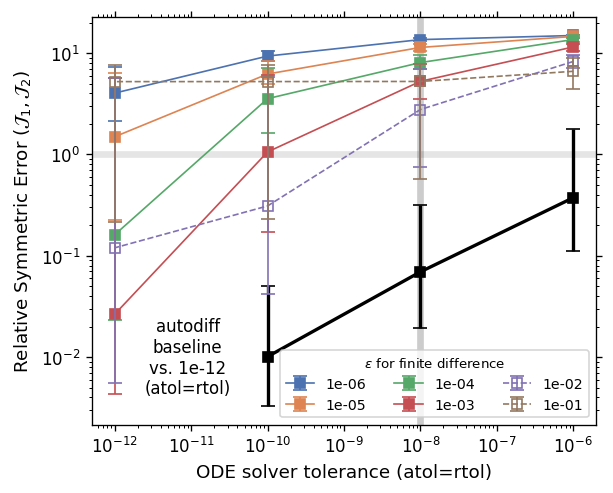

In [10]:
##### combined panel with percentile errorbars

fig, ax = plt.subplots(nrows=1,ncols=1,figsize=(5,4),constrained_layout=True)

### first auto-diff self-consistency tests
ax.errorbar(tols_ode[:3], jac_err_adself_norm[1],
            yerr=[jac_err_adself_norm[1]-jac_err_adself_norm[0],jac_err_adself_norm[2]-jac_err_adself_norm[1]],
            fmt='ks-',capsize=4,lw=2)

ax.text(9e-12,1e-2,'autodiff\nbaseline\nvs. 1e-12\n(atol=rtol)',color='k',fontsize=10,ha='center',va='center')

### now finite-diff vs autodiff for a given ode tol and eps_fdiff

eps_colors = [sns.color_palette('deep')[i] for i in range(len(epsilons))][::-1]
eps_lss = ['--','--','-','-','-','-'] # ['-','--',':','dashdot']
eps_mfc = ['none','none',None,None,None,None]
eps_m = ['s','s','s','s','s','s']
# eps_lws = [1.5,0.5,0.5,0.5]

for i,v in enumerate(epsilons):

    ax.errorbar(tols_ode, jac_err_compare_norm[1][i],
                yerr=[jac_err_compare_norm[1][i]-jac_err_compare_norm[0][i],jac_err_compare_norm[2][i]-jac_err_compare_norm[1][i]],
                fmt=eps_m[i],capsize=4,color=eps_colors[i],label='%.0e'%v,lw=1,ls=eps_lss[i],mfc=eps_mfc[i],
                zorder=len(epsilons)-1-i)

    
    # ax.loglog(tols_ode,jac_err_compare_norm2[i],marker='s',color=eps_colors[i],lw=1,label='%.0e'%v)

leg = ax.legend(loc='lower right',title=r'$\epsilon$ for finite difference',ncols=3,fontsize=8.5,title_fontsize=8,reverse=True)
# leg.get_title().set_ha('center')

ax.set_xscale('log')
ax.set_yscale('log')

ax.set_xlabel('ODE solver tolerance (atol=rtol)',fontsize=11)
# ax.set_ylabel(r'$\langle\; \parallel (\mathcal{J}_1-\mathcal{J}_2) / (\vert \mathcal{J}_1\vert + \vert \mathcal{J}_2\vert) \parallel \;\rangle$',
#               fontsize=12)
ax.set_ylabel(r'Relative Symmetric Error $(\mathcal{J}_1, \mathcal{J}_2)$',
              fontsize=11)

ax.axvline(1e-8,color='k',alpha=0.2,lw=4,zorder=0)
ax.axhline(1,color='k',alpha=0.1,lw=4,zorder=0)

# plt.savefig('finitediff_jacobians_mw.png',bbox_inches='tight',dpi=300,facecolor='w')


# Figure 22 of Pandya+26

In [12]:
### unpack data needed for Figure 22 of Pandya+26

final_mvirs = out_jacs['final_mvirs']
params_jac = out_jacs['params_jac']
tols_ode2 = out_jacs['tols_ode2']
fd8_err = out_jacs['fd8_err']
fd12_err = out_jacs['fd12_err']
ad_err = out_jacs['ad_err']

params_bounds = config['sampling_config']['params_bounds']




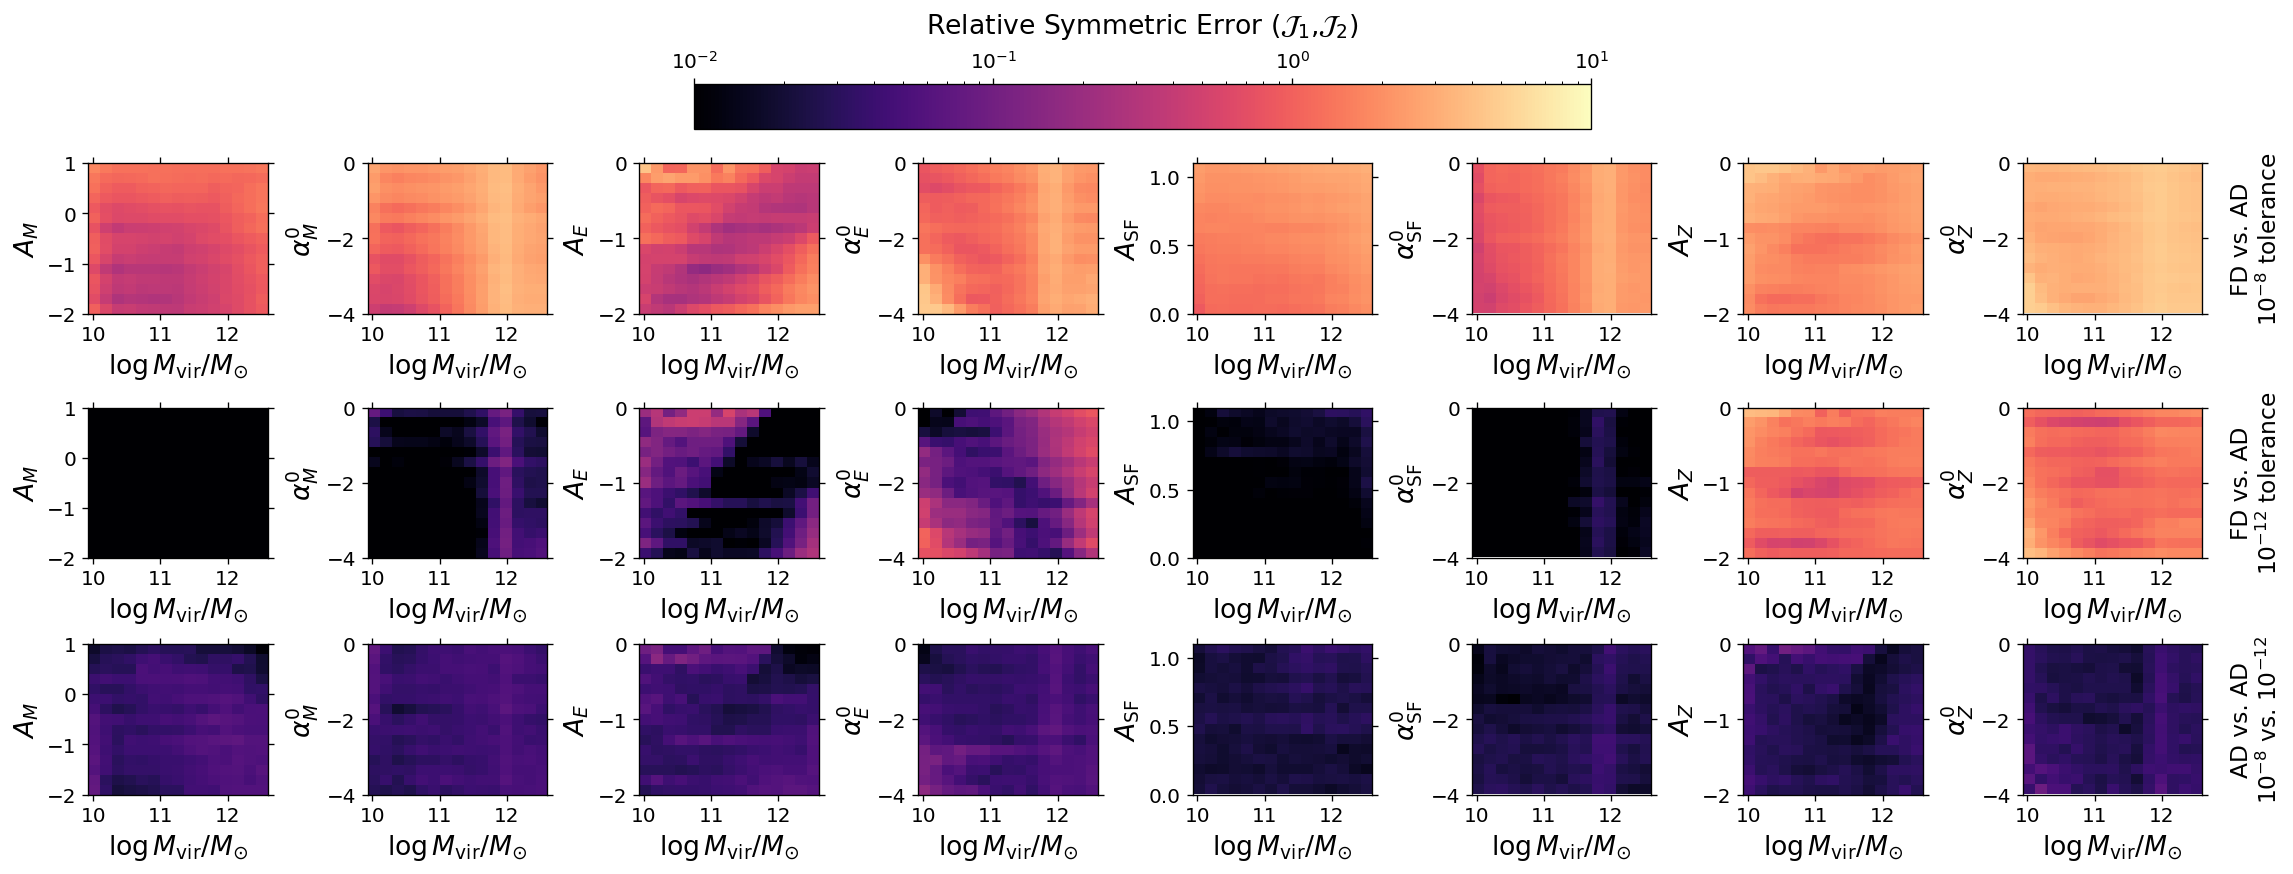

In [14]:

par_labels = {'A_M':r'$A_M$','alpha0_M':r'$\alpha_M^0$','A_E':r'$A_E$','alpha0_E':r'$\alpha_E^0$',
              'A_SF':r'$A_{\rm SF}$','alpha0_SF':r'$\alpha_{\rm SF}^0$',
              'A_Z':r'$A_Z$','alpha0_Z':r'$\alpha_Z^0$'}
param_names = list(par_labels.keys())

def jacnorm_hist2d_all(final_mvirs, params_jac, nbins_x=15, nbins_y=15):
    
    # Prepare figure
    fig, axes = plt.subplots(nrows=3, ncols=8, figsize=(19, 6), constrained_layout=True)
    allax = np.ravel(axes)


    ### Loop over the 3 types of err arrays

    for axrow, err_matrix in enumerate([fd8_err, fd12_err, ad_err]):
    
        # Loop over 9 parameters
        for i in range(8):
            x = np.repeat(final_mvirs[None, :], params_jac.shape[0], axis=0).flatten()  # shape (2K*1K,)
            y = np.repeat(params_jac[:, i][:, None], len(final_mvirs), axis=1).flatten()
            # z = jacnorm_totcol[:, :, i].flatten()
            # z = jnp.linalg.norm(ad_err, axis=(2,))[:,:,i].flatten()
            # z = jnp.linalg.norm(fd8_err, axis=(2,))[:,:,i].flatten()
            z = jnp.linalg.norm(err_matrix, axis=(2,))[:,:,i].flatten()
    
            # Compute 2D histogram
            # sum_vals, xedges, yedges = np.histogram2d(x, y, bins=[nbins_x, nbins_y], weights=z)
            # counts, _, _ = np.histogram2d(x, y, bins=[xedges, yedges])
    
            # Mask nan values
            z_valid = np.where(~np.isnan(z), z, 0.0)
            valid_mask = ~np.isnan(z)
            
            # Compute sum of valid weights and count of valid entries
            sum_vals, xedges, yedges = np.histogram2d(x, y, bins=[nbins_x, nbins_y], weights=z_valid)
            counts, _, _ = np.histogram2d(x, y, bins=[xedges, yedges], weights=valid_mask.astype(float))
            
            mean_vals = sum_vals / np.maximum(counts, 1)
            mean_vals = mean_vals.T  # for imshow
    
            # Plot each panel
            # ax = allax[i]
            ax = axes[axrow][i]
            img = ax.imshow(mean_vals, origin='lower', aspect='auto',
                            extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
                            cmap='magma', norm=LogNorm(vmin=1e-2,vmax=10))#vmin=0, vmax=1)
            
            ax.set_xlabel(r'$\log M_{\rm vir}/M_{\odot}$', fontsize=16)
            ax.set_ylabel(par_labels[param_names[i]], fontsize=16)
            ax.tick_params(labelsize=12)

            ax.set_ylim(params_bounds[param_names[i]])

    # Shared colorbar
    cax = inset_axes(axes[0][4], width="500%", height="30%", loc="upper center", borderpad=2,
                     bbox_transform=axes[0][3].transAxes, bbox_to_anchor=(0.75, 0.75, 1, 1))
    cbar = fig.colorbar(img, cax=cax, orientation='horizontal')
    # cbar.set_label(r'$\langle \frac{||\partial X_k / \partial \theta_j||}{||J||} \rangle$',fontsize=16)
    cbar.set_label(r'Relative Symmetric Error ($\mathcal{J}_1$,$\mathcal{J}_2$)',fontsize=16,labelpad=10)
    cax.xaxis.set_label_position('top',)
    cax.xaxis.set_ticks_position('top')
    cax.tick_params(labelsize=12)
        

    for ax in allax:
        ax.set_xticks(np.arange(10,13,1.0))

    axes[0][7].text(1.3,0.5,'FD vs. AD\n'+r'$10^{-8}$ tolerance',
                    transform=axes[0][7].transAxes,rotation=90,va='center',ha='center',fontsize=14)

    axes[1][7].text(1.3,0.5,'FD vs. AD\n'+r'$10^{-12}$ tolerance',
                    transform=axes[1][7].transAxes,rotation=90,va='center',ha='center',fontsize=14)

    axes[2][7].text(1.3,0.5,'AD vs. AD\n'+r'$10^{-8}$ vs. $10^{-12}$',
                    transform=axes[2][7].transAxes,rotation=90,va='center',ha='center',fontsize=14)

jacnorm_hist2d_all(final_mvirs, params_jac)

# plt.savefig('finitediff_jacobians_latinhypercube.png',bbox_inches='tight',facecolor='w',dpi=300)